## Import Merged Data Set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master_df = pd.read_csv('Team_Stats_Merge_2018_2025.csv')

In [3]:
master_df.info

<bound method DataFrame.info of      season                  team  tp_W  tp_L  tp_T  tp_W-L%  tp_PF  tp_PA  \
0      2018  New England Patriots    11     5   0.0    0.688    436    325   
1      2018        Miami Dolphins     7     9   0.0    0.438    319    433   
2      2018         Buffalo Bills     6    10   0.0    0.375    269    374   
3      2018         New York Jets     4    12   0.0    0.250    333    441   
4      2018      Baltimore Ravens    10     6   0.0    0.625    389    287   
..      ...                   ...   ...   ...   ...      ...    ...    ...   
251    2025    New Orleans Saints     6    11   0.0    0.353    306    383   
252    2025      Seattle Seahawks    14     3   0.0    0.824    483    292   
253    2025      Los Angeles Rams    12     5   0.0    0.706    518    346   
254    2025   San Francisco 49ers    12     5   0.0    0.706    437    371   
255    2025     Arizona Cardinals     3    14   0.0    0.176    355    488   

     tp_PD  tp_MoV  ...  def_ad

## Correlation Matrix

In [4]:
corr_matrix = master_df.corr(numeric_only=True)

In [5]:


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.85)
]

print(high_corr)

['tp_L', 'tp_W-L%', 'tp_PD', 'tp_MoV', 'tp_SRS', 'tp_OSRS', 'tp_DSRS', 'off_pts', 'off_yds', 'off_yds_per_play', 'off_penalty_yds', 'off_score_pct', 'off_turnover_pct', 'off_exp', 'def_g', 'def_pa', 'def_yds_per_play', 'def_score_pct', 'def_turnover_pct', 'def_exp', 'off_pass_G', 'off_pass_Att', 'off_pass_TD%', 'off_pass_Int', 'off_pass_Int%', 'off_pass_Y/A', 'off_pass_AY/A', 'off_pass_Y/G', 'off_pass_Rate', 'off_pass_Yds.1', 'off_pass_Sk%', 'off_pass_NY/A', 'off_pass_ANY/A', 'off_pass_EXP', 'off_rush_G', 'off_rush_Yds', 'off_rush_Y/G', 'def_pass_G', 'def_pass_Att', 'def_pass_TD%', 'def_pass_Int', 'def_pass_Int%', 'def_pass_Y/A', 'def_pass_AY/A', 'def_pass_Y/G', 'def_pass_Rate', 'def_pass_Yds.1', 'def_pass_Sk%', 'def_pass_NY/A', 'def_pass_ANY/A', 'def_pass_EXP', 'def_rush_G', 'def_rush_Y/G', 'def_adv_G', 'def_adv_Att', 'def_adv_Cmp', 'def_adv_Yds', 'def_adv_TD', 'def_adv_Sk', 'def_adv_Bltz%', 'def_adv_Hrry%', 'def_adv_QBKD%', 'def_adv_Prss%']


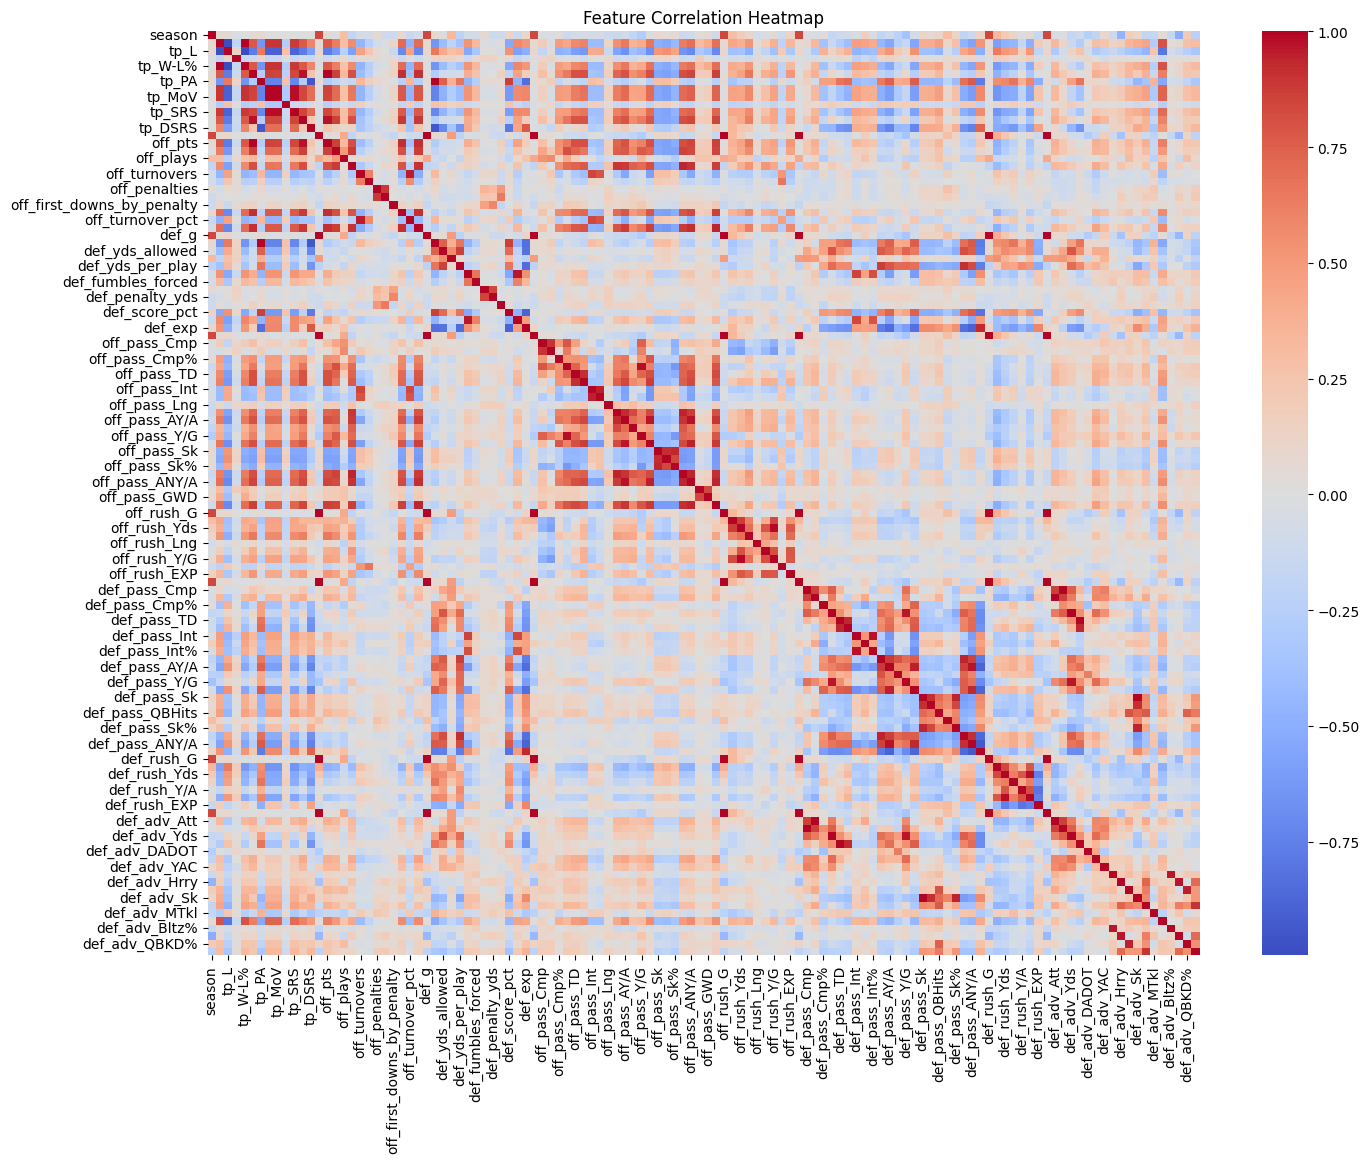

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(master_df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

## Establish Feautres

In [7]:
# Drop non-feature columns
drop_cols = ["season", "team", "made_playoffs"]  # adjust if needed

X = master_df.drop(columns=drop_cols)
y = master_df["made_playoffs"]

## Handle difference in inconsistent rates vs totals

We will add a 
* feature for fumble rate to be consistent with Int rate : off_Fmb% = off_fumbles/ off_plays * 100
* feature for fumble rate to be consistent with Int rate : off_rush_TD% = off_rush_TD / off_rush_Att * 100


In [8]:
X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
X['def_Fmb%'] = X['def_fumbles_forced']/X['def_plays']
X['off_rush_TD%'] = X['off_rush_TD']/X['off_rush_Att']
X['def_rush_TD%'] = X['def_rush_TD']/X['def_rush_Att']

/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_41074/1563296281.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_41074/1563296281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['def_Fmb%'] = X['def_fumbles_forced']/X['def_plays']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_41074/1563296281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

Number of all features

In [9]:
X.columns.size

122

## First Random Forest

Since there are is a huge number of features

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Check to see initial feature importance

In [11]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(25)

,feature,importance
3,tp_W-L%,0.119183
1,tp_L,0.105856
0,tp_W,0.097343
7,tp_MoV,0.061814
9,tp_SRS,0.047690
6,tp_PD,0.044412
13,off_pts,0.034852
4,tp_PF,0.032560
60,off_pass_EXP,0.019783
57,off_pass_ANY/A,0.018373


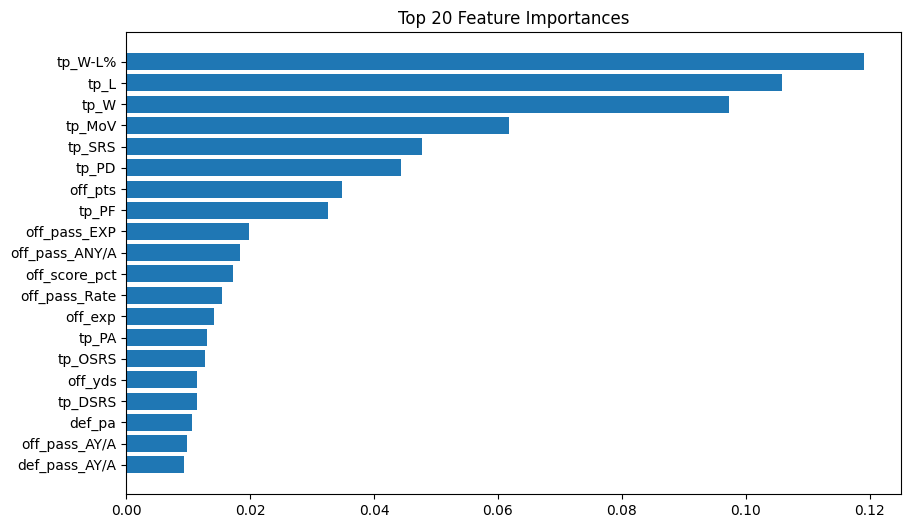

In [12]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

## Eliminate trival/nonrelevant features

Features that are obvious and should be remove because of noise.

Example:
Wins and scoring Points = playoffs 
Losses and giving up points != playoffs
Easier Schedule = playoffs

In [13]:
trivial_features = ['tp_W-L%',
                    'tp_W',
                    'tp_L',
                    'tp_PD',
                    'tp_MoV',
                    'tp_PF',
                    'tp_PA',
                    'tp_T',
                    'off_pts',
                    'def_pa',
                    'tp_SoS',
                    ]

## Eliminate aggregated / calculated features

These are features that will highly correlated and do not give signifcant interpretablebilty

Examples
* Anything with EXP/SRS (expect points and rating system) - not insightful - better teams get better ratings
* Total off/def yards - more interested in seeing passing and rushing splits not the total - 
* Total Efficiencies - more interested in seeing passing and rushing splits not the total - rush/pass Y/A instead of yds per play
* Efficieny > Volume - more interested in Yards/Attempt than Yards/Game
* Passing - Yards/Attempt > Yards/Completion - represents a better efficiency of yards gained per pass attempted rather than just the completed ones
* Rushing and Passing Attempt numbers as a whole falls under totals for me. After efficiency


In [14]:
aggregated_features = ['def_exp',
                       'off_exp',
                       'off_rush_exp',
                       'tp_SRS',
                        'tp_OSRS',
                        'tp_DSRS',
                       'off_yds',
                       'def_yds_allowed',
                       'def_pass_AY/A',
                       'off_pass_AY/A',
                       'off_pass_ANY/A',
                       'def_pass_ANY/A',
                       'off_rush_EXP',
                       'def_rush_EXP',
                        'off_pass_EXP',
                        'def_pass_EXP',
                        'off_yds_per_play',
                        'def_yds_per_play',
                        'off_rush_G',
                        'def_rush_G',
                        'def_adv_G',
                        'off_pass_G',
                        'def_pass_G',
                        'off_g',
                        'def_g',
                        'off_pass_Yds',
                        'def_rush_Yds',
                        'off_rush_Yds',
                        'def_pass_Yds',
                        'off_pass_Y/G',
                        'off_pass_Y/C',
                        'def_rush_Y/G',
                        'off_pass_TD',
                        'def_rush_Att',
                        'off_rush_Att',
                        'off_rush_Y/G',
                        'off_pass_Yds.1',
                        'def_pass_Yds.1',
                        'def_plays',
                        'off_plays',
                        'off_score_pct',
                        'def_score_pct',
                        'off_turnover_pct',
                        'def_turnover_pct',
                        'off_rush_Fmb',
                        'def_pass_Int',
                        'def_fumbles_forced',
                        'off_pass_Lng',
                        'off_turnovers',
                        'def_turnovers_forced',
                        'off_rush_TD',
                        'def_pass_Y/C',
                        'off_pass_Rate',
                        'def_pass_Rate',
                        'off_pass_Sk',
                        'def_pass_Sk',
                        'off_pass_Cmp',
                        'def_pass_Att',
                        'def_adv_Att',
                        'off_pass_Int',
                        'off_fumbles',
                        'off_pass_Int',
                        'def_rush_TD',
                        'off_rush_Lng',
                        'def_adv_Cmp',
                        'def_pass_Cmp',
                        'def_pass_TD',
                        'def_adv_Yds',
                        'def_pass_Y/G',
                        'def_adv_Bltz',
                        'def_pass_QBHits',
                        'off_pass_Att',
                        'def_adv_Sk',
                        'def_pass_Sk%',
                        'def_adv_Hrry',
                        'def_adv_Prss',
                        'def_adv_TD',
                        'off_pass_NY/A',
                        'def_pass_NY/A',
                        'def_adv_pass_TD%',
                        'def_adv_QBKD',
                        'off_fumbles'
                       ]

## Eliminate Situation Features

These are features that are too niche to the situation of the game. 

Examples
* Penalties - too random and obviously negative
* Game Winning Drives (GWD) - power house teams may not ever be in situation of GWD
* 4th Quarter Comback (4QC) - same as GWD


In [15]:
situational_features = ['off_penalties',
                        'def_penalties',
                        'def_penalty_yds',
                        'off_penalty_yds',
                        'off_pass_4QC',
                        'def_first_downs_by_penalty',
                        'off_first_downs_by_penalty',
                        'off_pass_GWD',
                        ]

In [16]:
X = X.drop(columns=trivial_features, errors='ignore')
X = X.drop(columns=aggregated_features, errors='ignore')
X = X.drop(columns=situational_features, errors='ignore')

## Second Random Forest

See feature importance now with reduced features

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance


,feature,importance
1,off_pass_TD%,0.119945
3,off_pass_Y/A,0.090912
10,def_pass_Y/A,0.057271
9,def_pass_Int%,0.054724
0,off_pass_Cmp%,0.053306
6,def_pass_Cmp%,0.052866
8,def_pass_PD,0.047286
7,def_pass_TD%,0.046703
4,off_pass_Sk%,0.046036
14,def_adv_Air,0.043182


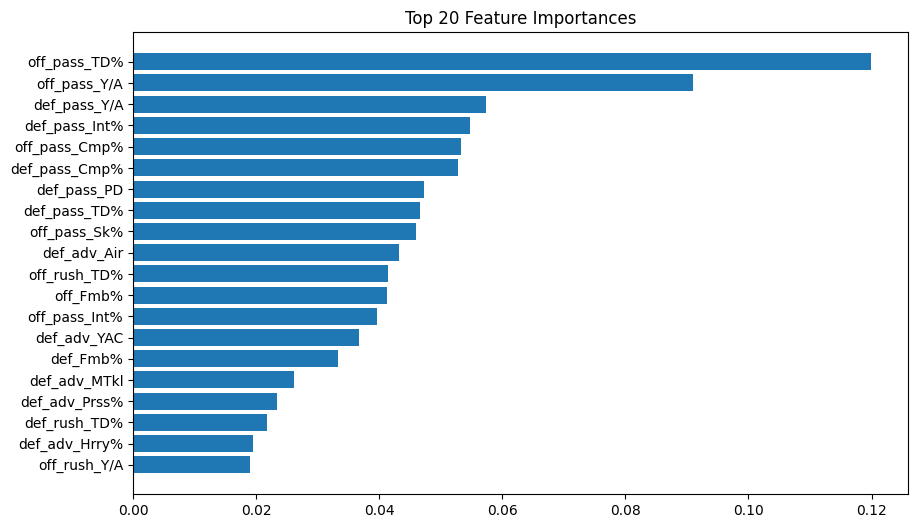

In [19]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

Noticed a missing value when trying to run Logistic Regression - Jets had 0 ints in 2025

In [20]:
print("Shape:", X.shape)
print("Any NaN?", X.isna().sum().sum())
print("Any inf?", np.isinf(X).sum().sum())

Shape: (256, 25)
Any NaN? 1
Any inf? 0


In [21]:
print(X.isna().sum()[X.isna().sum() > 0])

def_pass_Int%    1
dtype: int64


In [22]:
mask = X["def_pass_Int%"].isna()

print(master_df.loc[mask, ["season", "team", "def_pass_Att", "def_pass_Int"]])

     season           team  def_pass_Att  def_pass_Int
227    2025  New York Jets           515           NaN


In [23]:
X["def_pass_Int%"] = X["def_pass_Int%"].fillna(0)

## Compares Model Performance

Comparing Logistic Regression and Random Forest

### Logistic Regression (LR)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# 1. Same split for both models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2120,
    stratify=y
)

# 2. Scale only for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# 4. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# 5. Collect comparison metrics
model_compare = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print(model_compare)

                 Model  Accuracy       AUC
0  Logistic Regression  0.884615  0.960606
1        Random Forest  0.865385  0.953030


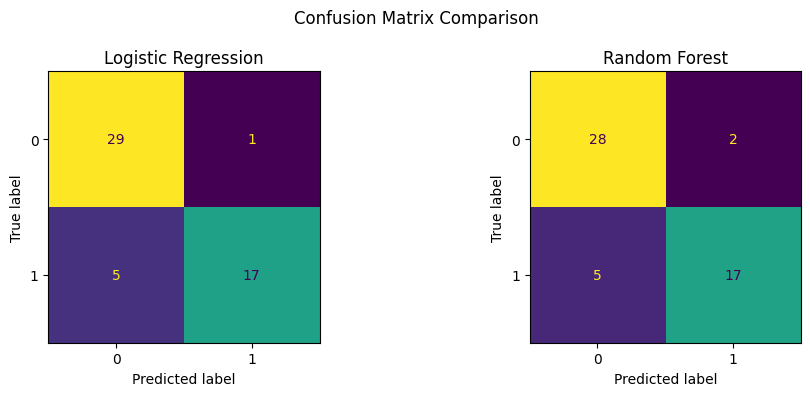

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Logistic predictions
log_cm = confusion_matrix(y_test, log_pred)

# Random forest predictions
rf_cm = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(log_cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(rf_cm).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()

In [34]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, log_pred), accuracy_score(y_test, rf_pred)],
    "AUC": [roc_auc_score(y_test, log_prob), roc_auc_score(y_test, rf_prob)],
    "Playoff Precision": [
        classification_report(y_test, log_pred, output_dict=True)["1"]["precision"],
        classification_report(y_test, rf_pred, output_dict=True)["1"]["precision"]
    ],
    "Playoff Recall": [
        classification_report(y_test, log_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, rf_pred, output_dict=True)["1"]["recall"]
    ],
    "Playoff F1": [
        classification_report(y_test, log_pred, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, rf_pred, output_dict=True)["1"]["f1-score"]
    ]
})

print(comparison_table.round(3))

                 Model  Accuracy    AUC  Playoff Precision  Playoff Recall  \
0  Logistic Regression     0.885  0.961              0.944           0.773   
1        Random Forest     0.865  0.953              0.895           0.773   

   Playoff F1  
0       0.850  
1       0.829  


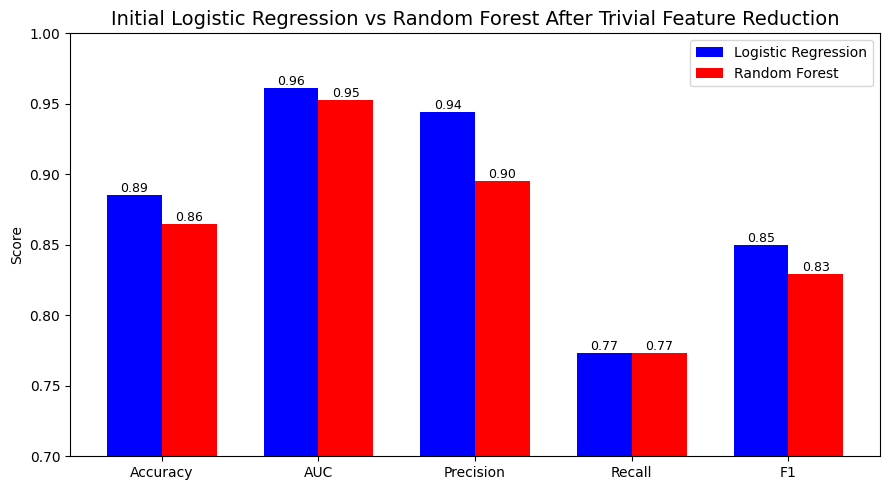

In [98]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1"]

lr_values = [0.885, 0.961, 0.944, 0.773, 0.850]
rf_values = [0.865, 0.953, 0.895, 0.773, 0.829]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, lr_values, width, label="Logistic Regression", color="blue")
plt.bar(x + width/2, rf_values, width, label="Random Forest", color="red")

# value labels
for i, v in enumerate(lr_values):
    plt.text(i - width/2, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

for i, v in enumerate(rf_values):
    plt.text(i + width/2, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0.7, 1.0)
plt.ylabel("Score")
plt.title("Initial Logistic Regression vs Random Forest After Trivial Feature Reduction", fontsize=14)


plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# OLD COMPARISON - DID NOT LIKE THE TWO DIFFERENT STATES THAT THEY WERE RAN ON 

'''

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------
# 2. Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2120,
)

# ---------------------------
# 3. Scale Features (IMPORTANT for Logistic)
# ---------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# 4. Initialize Model
# ---------------------------
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ---------------------------
# 5. Train Model
# ---------------------------
log_model.fit(X_train_scaled, y_train)

# ---------------------------
# 6. Predictions
# ---------------------------
y_pred = log_model.predict(X_test_scaled)

# ---------------------------
# 7. Evaluation
# ---------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

RESULT
Accuracy: 0.8846153846153846

Confusion Matrix:
 [[28  5]
 [ 1 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.78      0.95      0.86        19

    accuracy                           0.88        52
   macro avg       0.87      0.90      0.88        52
weighted avg       0.90      0.88      0.89        52
'''


'\n\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report\n\n# ---------------------------\n# 2. Train/Test Split\n# ---------------------------\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y,\n    test_size=0.2,\n    random_state=2120,\n)\n\n# ---------------------------\n# 3. Scale Features (IMPORTANT for Logistic)\n# ---------------------------\nscaler = StandardScaler()\n\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\n# ---------------------------\n# 4. Initialize Model\n# ---------------------------\nlog_model = LogisticRegression(\n    max_iter=1000,\n    random_state=42\n)\n\n# ---------------------------\n# 5. Train Model\n# ---------------------------\nlog_model.fit(X_train_scaled, y_train)\n\n# ---------------------------\n# 6. P

### Random Forest (RF)

In [46]:
# OLD COMPARISON - DID NOT LIKE THE TWO DIFFERENT STATES THAT THEY WERE RAN ON 

'''
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state= 2120,
    
)

model.fit(X_train, y_train)
# ---------------------------
# 4. Train Model
# ---------------------------
model.fit(X_train, y_train)

# ---------------------------
# 5. Predictions
# ---------------------------
y_pred = model.predict(X_test)

# ---------------------------
# 6. Evaluation
# ---------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

RESULT
Accuracy: 0.8076923076923077

Confusion Matrix:
 [[26  2]
 [ 8 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.93      0.84        28
           1       0.89      0.67      0.76        24

    accuracy                           0.81        52
   macro avg       0.83      0.80      0.80        52
weighted avg       0.82      0.81      0.80        52
'''

'\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import train_test_split\n\n# Simple split (this is fine for feature importance)\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)\n\nmodel = RandomForestClassifier(\n    n_estimators=200,\n    random_state= 2120,\n\n)\n\nmodel.fit(X_train, y_train)\n# ---------------------------\n# 4. Train Model\n# ---------------------------\nmodel.fit(X_train, y_train)\n\n# ---------------------------\n# 5. Predictions\n# ---------------------------\ny_pred = model.predict(X_test)\n\n# ---------------------------\n# 6. Evaluation\n# ---------------------------\nprint("Accuracy:", accuracy_score(y_test, y_pred))\nprint("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))\nprint("\nClassification Report:\n", classification_report(y_test, y_pred))\n\nRESULT\nAccuracy: 0.8076923076923077\n\nConfusion Matrix:\n [[26  2]\n [ 8 16]]\n\nClassification Report:\n         

LR performed better with 0.8846153846153846 vs RFs 0.7884615384615384 accuracy

Since LR performed better I'm leaning towards checking VIF scores since LR does not like highly correlated variables

## Variance inflation factor (VIF)

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
print(vif)

          Feature         VIF
6   def_pass_Cmp%  863.610071
20  def_adv_Prss%  784.671790
10   def_pass_Y/A  689.862849
0   off_pass_Cmp%  646.153614
3    off_pass_Y/A  375.116370
13  def_adv_DADOT  295.510438
5    off_rush_Y/A  187.503308
12   def_rush_Y/A  184.589347
18  def_adv_Hrry%  159.147091
14    def_adv_Air  143.696644
15    def_adv_YAC  116.082374
19  def_adv_QBKD%  115.983223
11   def_pass_TFL   72.680746
8     def_pass_PD   68.092390
1    off_pass_TD%   48.578972
7    def_pass_TD%   48.051730
16   def_adv_MTkl   36.204102
24   def_rush_TD%   28.048763
23   off_rush_TD%   28.017413
4    off_pass_Sk%   19.218739
17  def_adv_Bltz%   17.217087
9   def_pass_Int%   15.760731
2   off_pass_Int%   15.450138
22       def_Fmb%   12.930336
21       off_Fmb%   12.036601


Having many variables way up in the hundreds shows that they are highly correlated to other variables

/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_41074/1381484094.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


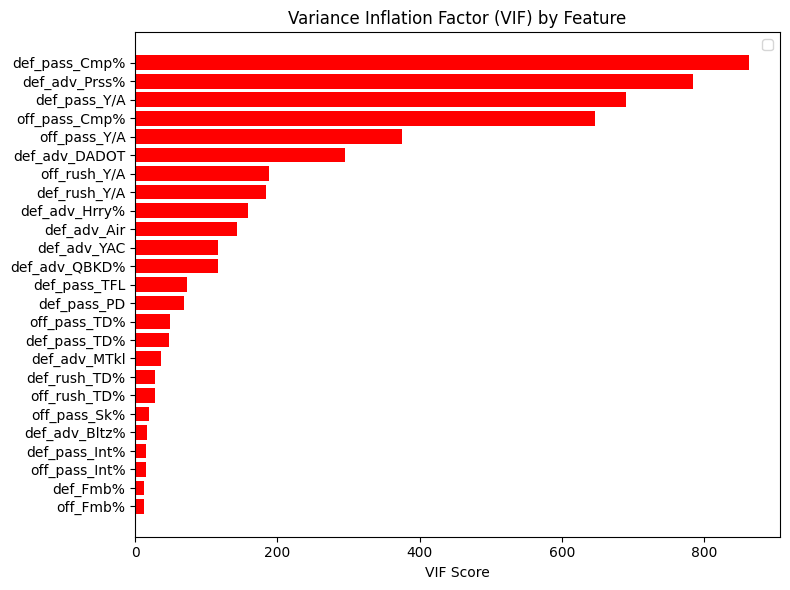

In [96]:
import matplotlib.pyplot as plt

# sort for plotting (ascending so biggest at top visually)
vif_plot = vif.sort_values("VIF", ascending=True)

# color code
colors = ["red" if v > 10 else "blue" for v in vif_plot["VIF"]]

plt.figure(figsize=(8,6))

plt.barh(vif_plot["Feature"], vif_plot["VIF"], color=colors)


plt.xlabel("VIF Score")
plt.title("Variance Inflation Factor (VIF) by Feature")

plt.legend()
plt.tight_layout()
plt.show()

### After Running the VIF eliminate extreme values

In [49]:
## Initial instrict was to get rid of completion percentage, felt not that insightful conceptually
# have some of the highest of the highest VIF

VIF_features = ['off_pass_Cmp%',
                'def_pass_Cmp%'
                ]

In [50]:
X = X.drop(columns=VIF_features, errors='ignore')
y = master_df["made_playoffs"]

Grouped features into categories, going to run every combo possible for one variable in each category. These were to address correlated features

In [51]:

# odd man out features
fixed_features = [
    "off_pass_Sk%",
    "def_pass_TFL",
]

# grouped alternatives: choose ONE from each group
feature_groups = {
    "off_pass_eff": ["off_pass_Y/A", "off_pass_TD%"],
    "def_pass_eff": ["def_pass_Y/A", "def_pass_PD", "def_pass_TD%"],
    "off_rush_score": ["off_rush_TD%","off_rush_Y/A"],
    "def_rush_score": ["def_rush_TD%","def_rush_Y/A"],
    "pressure": ["def_adv_Hrry%","def_adv_QBKD%","def_adv_Prss%","def_adv_Bltz%"],
    "def_turnover_eff": ["def_Fmb%","def_pass_Int%"],
    "off_turnover_eff": ["off_Fmb%","off_pass_Int%"]
    }


performed every combo of each category against LR and RF Models

### LR

In [52]:
import itertools
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

results = []

group_names = list(feature_groups.keys())
group_options = [feature_groups[name] for name in group_names]

for combo in itertools.product(*group_options):
    selected_features = fixed_features + list(combo)

    X_temp = X[selected_features].copy()
    y = master_df["made_playoffs"].copy()

    # numeric only
    X_temp = X_temp.select_dtypes(include=["number"]).copy()

    # handle missing
    X_temp = X_temp.fillna(X_temp.median(numeric_only=True))

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y, test_size=0.2, random_state=2120, stratify=y
    )

    # scale (VERY IMPORTANT)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # logistic model
    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    row = {
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    # track group selections
    for name, feat in zip(group_names, combo):
        row[name] = feat

    results.append(row)

results_df_lr = pd.DataFrame(results).sort_values(
    ["accuracy", "f1"], ascending=False
)

print(results_df_lr.head(10))

                                              features  accuracy        f1  \
219  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.903846  0.883721   
223  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.903846  0.883721   
251  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.903846  0.883721   
279  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.903846  0.883721   
10   [off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...  0.884615  0.863636   
42   [off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...  0.884615  0.863636   
222  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.884615  0.863636   
266  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.884615  0.863636   
270  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.884615  0.863636   
278  [off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...  0.884615  0.863636   

     off_pass_eff  def_pass_eff off_rush_score def_rush_score       pressure  \
219  off_pass_TD%  def_pass_Y/A   off_rush_TD%   def_rush_Y/A

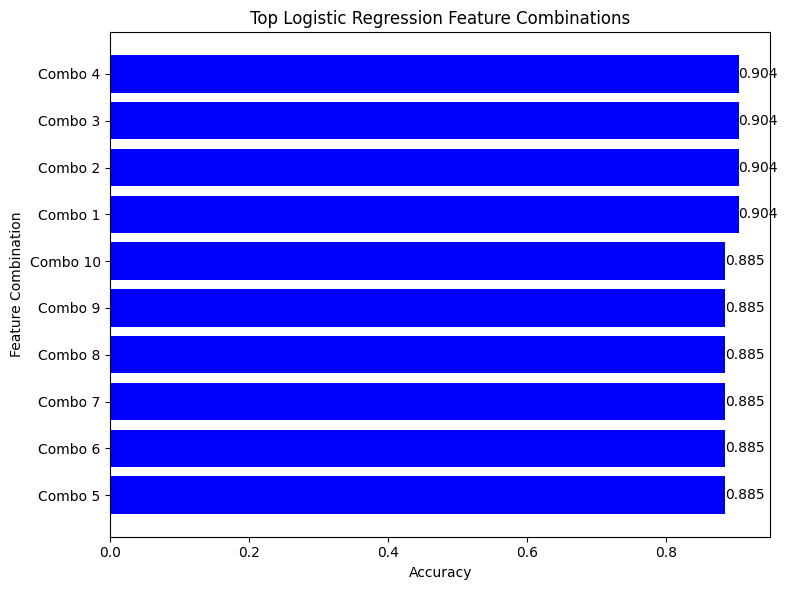

In [58]:
top_df = results_df_lr.head(10).copy()

top_df["combo_id"] = [f"Combo {i+1}" for i in range(len(top_df))]

top_df = top_df.sort_values("accuracy", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_df["combo_id"], top_df["accuracy"], color="blue")

for i, v in enumerate(top_df["accuracy"]):
    plt.text(v, i, f"{v:.3f}", va="center")

plt.xlabel("Accuracy")
plt.ylabel("Feature Combination")
plt.title("Top Logistic Regression Feature Combinations")

plt.tight_layout()
plt.show()

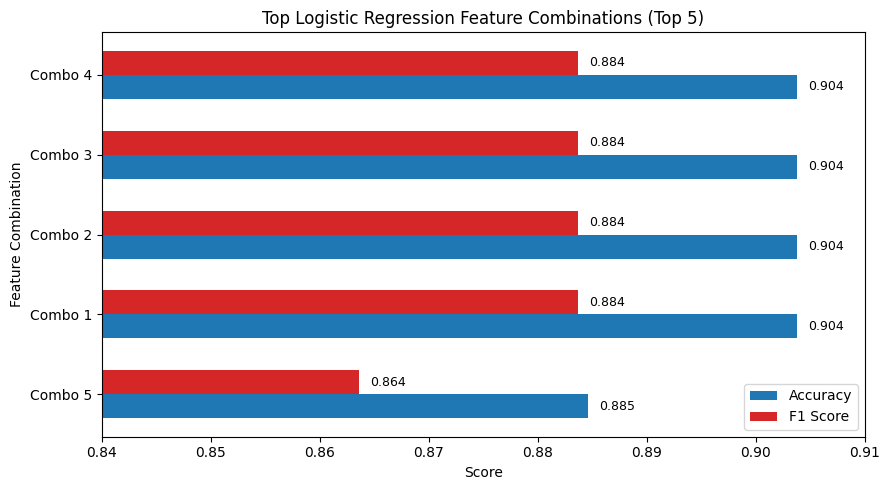

In [61]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 5
top_df = results_df_lr.head(top_n).copy()

# label combos
top_df["combo_id"] = [f"Combo {i+1}" for i in range(len(top_df))]

# sort for plotting
top_df = top_df.sort_values("accuracy", ascending=True).reset_index(drop=True)

y = np.arange(len(top_df))
height = 0.3

plt.figure(figsize=(9,5))

# colors
color_acc = "#1f77b4"
color_f1 = "#d62728"

# bars
plt.barh(y - height/2, top_df["accuracy"], height, color=color_acc, label="Accuracy")
plt.barh(y + height/2, top_df["f1"], height, color=color_f1, label="F1 Score")

# labels
for i, v in enumerate(top_df["accuracy"]):
    plt.text(v + 0.001, y[i] - height/2, f"{v:.3f}", va="center", fontsize=9)

for i, v in enumerate(top_df["f1"]):
    plt.text(v + 0.001, y[i] + height/2, f"{v:.3f}", va="center", fontsize=9)

plt.yticks(y, top_df["combo_id"])
plt.xlabel("Score")
plt.ylabel("Feature Combination")

# tighten axis to emphasize similarity
plt.xlim(0.84, 0.91)

plt.title("Top Logistic Regression Feature Combinations (Top 5)")

plt.legend()
plt.tight_layout()
plt.show()

In [62]:
top_n = 5
top_df = results_df_lr.head(top_n).copy().reset_index(drop=True)

# assign combo labels
top_df["combo_id"] = [f"Combo {i+1}" for i in range(len(top_df))]

# select columns you want to show
combo_table = top_df[["combo_id", "accuracy", "f1"] + group_names]

print(combo_table)

  combo_id  accuracy        f1  off_pass_eff  def_pass_eff off_rush_score  \
0  Combo 1  0.903846  0.883721  off_pass_TD%  def_pass_Y/A   off_rush_TD%   
1  Combo 2  0.903846  0.883721  off_pass_TD%  def_pass_Y/A   off_rush_TD%   
2  Combo 3  0.903846  0.883721  off_pass_TD%  def_pass_Y/A   off_rush_Y/A   
3  Combo 4  0.903846  0.883721  off_pass_TD%   def_pass_PD   off_rush_TD%   
4  Combo 5  0.884615  0.863636  off_pass_Y/A  def_pass_Y/A   off_rush_TD%   

  def_rush_score       pressure def_turnover_eff off_turnover_eff  
0   def_rush_Y/A  def_adv_Prss%    def_pass_Int%    off_pass_Int%  
1   def_rush_Y/A  def_adv_Bltz%    def_pass_Int%    off_pass_Int%  
2   def_rush_Y/A  def_adv_Prss%    def_pass_Int%    off_pass_Int%  
3   def_rush_Y/A  def_adv_QBKD%    def_pass_Int%    off_pass_Int%  
4   def_rush_TD%  def_adv_Prss%    def_pass_Int%         off_Fmb%  


## RF

In [64]:
# NOT COMPARING TO RF ANYMORE... WAS DONE PREVIOUSLY ABOVE

'''
import itertools
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


results = []

group_names = list(feature_groups.keys())
group_options = [feature_groups[name] for name in group_names]

for combo in itertools.product(*group_options):
    selected_features = fixed_features + list(combo)

    X_temp = X[selected_features].copy()
    y = master_df["made_playoffs"].copy()

    # keep numeric only just in case
    X_temp = X_temp.select_dtypes(include=["number"]).copy()

    # handle missing values
    X_temp = X_temp.fillna(X_temp.median(numeric_only=True))

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    row = {
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    # save which option was chosen from each group
    for name, feat in zip(group_names, combo):
        row[name] = feat

    results.append(row)

results_df = pd.DataFrame(results).sort_values(
    ["accuracy", "f1"], ascending=False
)

print(results_df.head(10))
'''

'\nimport itertools\nimport pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import accuracy_score, f1_score\n\n\nresults = []\n\ngroup_names = list(feature_groups.keys())\ngroup_options = [feature_groups[name] for name in group_names]\n\nfor combo in itertools.product(*group_options):\n    selected_features = fixed_features + list(combo)\n\n    X_temp = X[selected_features].copy()\n    y = master_df["made_playoffs"].copy()\n\n    # keep numeric only just in case\n    X_temp = X_temp.select_dtypes(include=["number"]).copy()\n\n    # handle missing values\n    X_temp = X_temp.fillna(X_temp.median(numeric_only=True))\n\n    X_train, X_test, y_train, y_test = train_test_split(\n        X_temp, y, test_size=0.2, random_state=42\n    )\n\n    model = RandomForestClassifier(\n        n_estimators=200,\n        random_state=42\n    )\n    model.fit(X_train, y_train)\n\n    y_pred = model.predict(X_tes

LR still performed better and discovered the best features to have in each category

## Final Features

In [65]:
final_features = [
    # Passing (efficiency + mistakes)
    "off_pass_TD%",
    "off_pass_Int%",
    
    # Defensive passing disruption
    "def_pass_Y/A",
    
    # Rushing
    "off_rush_TD%",
    "def_rush_Y/A",
    
    # Turnovers
    "def_pass_Int%",
    
    # Pressure (choose one)
    "def_adv_Prss%"   # or def_adv_Prss%
]

In [66]:
X_final = X[final_features].copy()
y = master_df["made_playoffs"].copy()

# safety clean
X_final = X_final.replace([np.inf, -np.inf], np.nan)
X_final = X_final.fillna(X_final.median(numeric_only=True))

Checking VIF now

In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df["Feature"] = X_final.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_final.values, i)
    for i in range(X_final.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)
print(vif_df)

         Feature         VIF
2   def_pass_Y/A  114.809149
4   def_rush_Y/A  109.081627
6  def_adv_Prss%   40.239346
0   off_pass_TD%   15.581299
3   off_rush_TD%   13.903510
5  def_pass_Int%   10.577061
1  off_pass_Int%   10.515280


/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_41074/1959895875.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


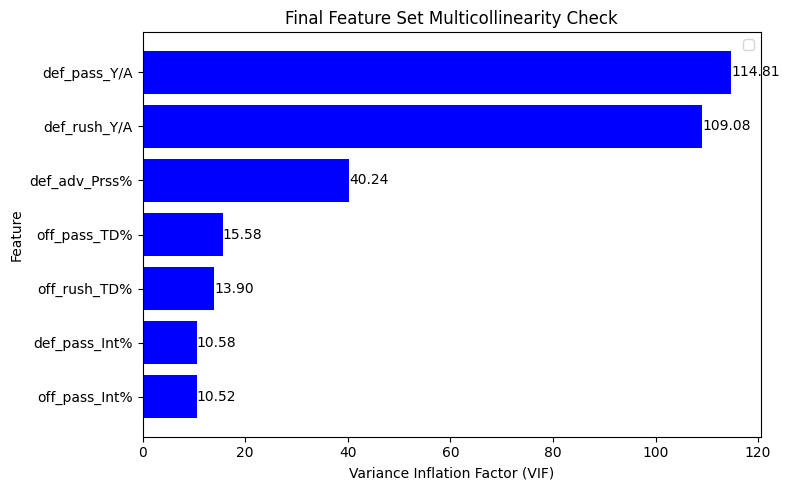

In [95]:
import matplotlib.pyplot as plt

vif_plot = vif_df.sort_values("VIF", ascending=True)

plt.figure(figsize=(8,5))

plt.barh(vif_plot["Feature"], vif_plot["VIF"], color="blue")

# value labels
for i, v in enumerate(vif_plot["VIF"]):
    plt.text(v, i, f"{v:.2f}", va="center")


plt.xlabel("Variance Inflation Factor (VIF)")
plt.ylabel("Feature")
plt.title("Final Feature Set Multicollinearity Check")

plt.legend()
plt.tight_layout()
plt.show()

See a big difference of how much the variable interact with each other

In [71]:
# SAME split for both models
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=2120,
    stratify=y
)

# Scale ONLY for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------
# Logistic Regression
# -----------------------
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# -----------------------
# Random Forest
# -----------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [74]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, log_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

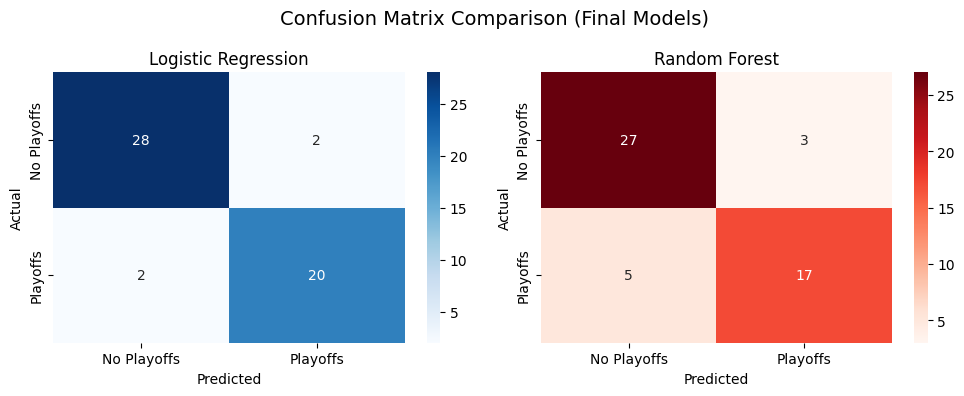

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Playoffs', 'Playoffs'],
            yticklabels=['No Playoffs', 'Playoffs'],
            ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Playoffs', 'Playoffs'],
            yticklabels=['No Playoffs', 'Playoffs'],
            ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison (Final Models)", fontsize=14)
plt.tight_layout()
plt.show()

In [73]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, log_pred))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.91      0.91      0.91        22

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.85      0.77      0.81        22

    accuracy                           0.85        52
   macro avg       0.85      0.84      0.84        52
weighted avg       0.85      0.85      0.84        52



In [76]:
from sklearn.metrics import classification_report

# Get reports as dictionaries
lr_report = classification_report(y_test, log_pred, output_dict=True)
rf_report = classification_report(y_test, rf_pred, output_dict=True)

# Pull metrics for playoff class (class = 1)
lr_precision = lr_report['1']['precision']
lr_recall = lr_report['1']['recall']
lr_f1 = lr_report['1']['f1-score']

rf_precision = rf_report['1']['precision']
rf_recall = rf_report['1']['recall']
rf_f1 = rf_report['1']['f1-score']

from sklearn.metrics import accuracy_score, roc_auc_score

lr_accuracy = accuracy_score(y_test, log_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

lr_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

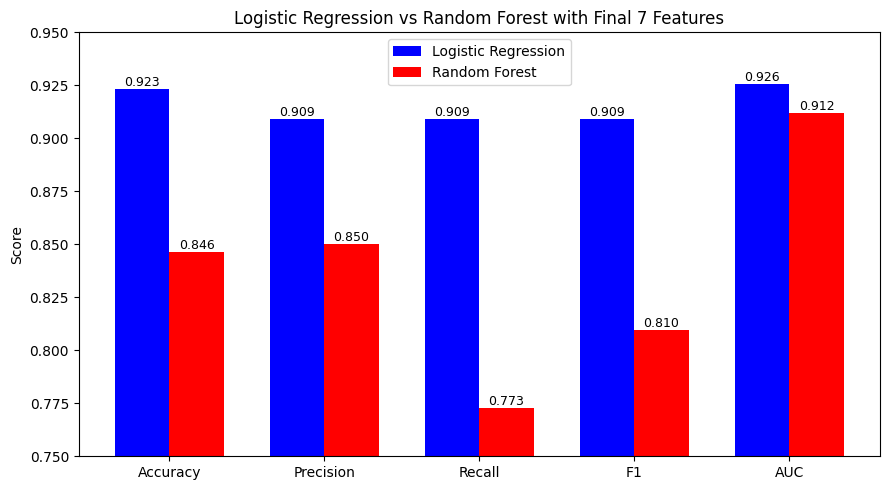

In [99]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

lr_values = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_auc]
rf_values = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(x - width/2, lr_values, width, color="blue", label="Logistic Regression")
bars2 = plt.bar(x + width/2, rf_values, width, color="red", label="Random Forest")

# Add labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h,
                 f"{h:.3f}", ha='center', va='bottom', fontsize=9)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0.75, 0.95)
plt.title("Logistic Regression vs Random Forest with Final 7 Features")
plt.legend()
plt.tight_layout()
plt.show()

## Timeseries Split

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ---------------------------
# 2. Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=2120,
    stratify=y
)

# ---------------------------
# 3. Scale Features (IMPORTANT for Logistic)
# ---------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# 4. Initialize Model
# ---------------------------
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ---------------------------
# 5. Train Model
# ---------------------------
log_model.fit(X_train_scaled, y_train)

# ---------------------------
# 6. Predictions
# ---------------------------
y_pred = log_model.predict(X_test_scaled)

# ---------------------------
# 7. Evaluation
# ---------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231

Confusion Matrix:
 [[28  2]
 [ 2 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.91      0.91      0.91        22

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52



In [86]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

ts_accuracies = []

for train_idx, test_idx in tscv.split(X_final):
    
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    ts_accuracies.append(acc)

print("TimeSeries Accuracies:", ts_accuracies)
print("Average Accuracy:", round(np.mean(ts_accuracies), 3))
print("Std Dev:", round(np.std(ts_accuracies), 3))

TimeSeries Accuracies: [0.8571428571428571, 0.6904761904761905, 0.7857142857142857, 0.8333333333333334, 0.8333333333333334]
Average Accuracy: 0.8
Std Dev: 0.059


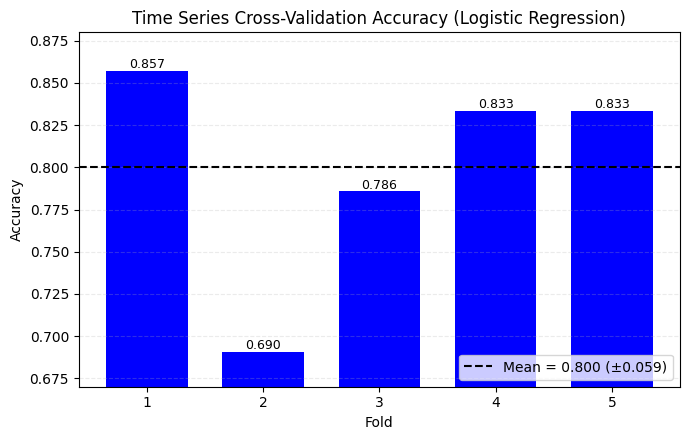

In [92]:
plt.figure(figsize=(7,4.5))

plt.bar(folds, ts_accuracies, color="blue", width=0.7)

# mean line
plt.axhline(
    mean_acc,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=f"Mean = {mean_acc:.3f} (±{std_acc:.3f})"
)

# labels on bars (raise slightly more)
for i, acc in enumerate(ts_accuracies):
    plt.text(
        folds[i],
        acc -0.0001,   # increased spacing to avoid overlap
        f"{acc:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Time Series Cross-Validation Accuracy (Logistic Regression)")

plt.xticks(folds)

# tighten y-axis slightly more for clarity
plt.ylim(0.67, 0.88)

# cleaner grid
plt.grid(axis='y', linestyle='--', alpha=0.25)

# 🔥 move legend OUTSIDE the plot
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

## KFolds (Removed)

In [93]:
## REALIZED NOT THE BEST FOR TIME SERIES SPLIT

'''

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

kf = KFold(n_splits=5, shuffle=False)

accuracies = []

for train_idx, test_idx in kf.split(X_final):
    
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    accuracies.append(acc)

print("Fold Accuracies:", accuracies)
print("Average Accuracy:", round(np.mean(accuracies), 3))
print("Std Dev:", round(np.std(accuracies), 3))
'''

'\n\nfrom sklearn.model_selection import KFold\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nimport numpy as np\n\nkf = KFold(n_splits=5, shuffle=False)\n\naccuracies = []\n\nfor train_idx, test_idx in kf.split(X_final):\n\n    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]\n    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\n\n    scaler = StandardScaler()\n    X_train = scaler.fit_transform(X_train)\n    X_test = scaler.transform(X_test)\n\n    model = LogisticRegression()\n    model.fit(X_train, y_train)\n\n    acc = model.score(X_test, y_test)\n    accuracies.append(acc)\n\nprint("Fold Accuracies:", accuracies)\nprint("Average Accuracy:", round(np.mean(accuracies), 3))\nprint("Std Dev:", round(np.std(accuracies), 3))\n'

In [94]:
## REALIZED NOT THE BEST FOR TIME SERIES SPLIT

'''
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, len(accuracies) + 1)
mean_acc = np.mean(accuracies)

plt.figure(figsize=(6,4))

# bars
plt.bar(folds, accuracies, color='blue')

# mean line
plt.axhline(mean_acc, linestyle='--', color='black', label=f"Mean = {mean_acc:.3f}")

# labels on bars
for i, acc in enumerate(accuracies):
    plt.text(folds[i], acc, f"{acc:.3f}", ha='center', va='bottom', fontsize=9)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross-Validation Accuracy (Logistic Regression)")
plt.xticks(folds)
plt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.05)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
'''

'\nimport matplotlib.pyplot as plt\nimport numpy as np\n\nfolds = np.arange(1, len(accuracies) + 1)\nmean_acc = np.mean(accuracies)\n\nplt.figure(figsize=(6,4))\n\n# bars\nplt.bar(folds, accuracies, color=\'blue\')\n\n# mean line\nplt.axhline(mean_acc, linestyle=\'--\', color=\'black\', label=f"Mean = {mean_acc:.3f}")\n\n# labels on bars\nfor i, acc in enumerate(accuracies):\n    plt.text(folds[i], acc, f"{acc:.3f}", ha=\'center\', va=\'bottom\', fontsize=9)\n\nplt.xlabel("Fold")\nplt.ylabel("Accuracy")\nplt.title("K-Fold Cross-Validation Accuracy (Logistic Regression)")\nplt.xticks(folds)\nplt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.05)\n\nplt.legend()\nplt.grid(axis=\'y\', linestyle=\'--\', alpha=0.4)\n\nplt.tight_layout()\nplt.show()\n'

Both perform very well for having 7 features

## Save model_ready DF

In [75]:
model_df = pd.concat(
    [
        master_df[["season","team"]],  # identifiers
        X_final,
        y
    ],
    axis=1
)

model_df

,season,team,off_pass_TD%,off_pass_Int%,def_pass_Y/A,off_rush_TD%,def_rush_Y/A,def_pass_Int%,def_adv_Prss%,made_playoffs
0,2018,New England Patriots,5.1,1.9,6.9,0.037657,4.9,3.0,0.232,1
1,2018,Miami Dolphins,5.7,2.9,8.2,0.018868,4.8,4.1,0.258,0
2,2018,Buffalo Bills,2.6,4.6,6.3,0.032051,4.2,3.3,0.280,0
3,2018,New York Jets,3.4,3.6,7.5,0.026829,4.6,2.2,0.241,0
4,2018,Baltimore Ravens,3.2,1.6,6.3,0.034735,3.7,2.1,0.289,1
...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,3.2,2.0,6.8,0.020690,4.0,2.0,0.247,0
252,2025,Seattle Seahawks,5.2,3.1,6.0,0.037475,3.7,3.0,0.261,1
253,2025,Los Angeles Rams,7.7,1.3,6.8,0.036559,4.3,2.7,0.263,1
254,2025,San Francisco 49ers,5.7,2.8,7.0,0.031185,4.3,1.0,0.167,1


In [76]:
model_df.to_csv("team_stats_model_ready.csv", index=False)